### This segment of code downloads the data, skip if data already available

In [ ]:
# import wandb
# from tqdm import tqdm
# import numpy as np

# api = wandb.Api()

# def load_lcbench_varying_cost_runs(data, acq):
#     runs = api.runs(path="ziv-scully-group/LCBench-full", filters={
#         "sweep": "4y1hm71n",
#         "config.dataset_name": data,
#         "config.acquisition_function": acq},
#         )
    
#     configs_and_metrics = []
#     for run in runs:
#         metric_keys = ["config id", "estimated cumulative cost", "cumulative cost", "current best id", "current best observed", "StablePBGI(1e-3) acq", "StablePBGI(1e-4) acq", "StablePBGI(1e-5) acq", "LogEIPC acq", "regret upper bound", "exp min regret gap", "PRB"]
#         history = list(run.scan_history(keys = metric_keys, page_size=1_000_000_000))
#         metrics = {k: [d[k] for d in history] for k in metric_keys}
#         configs_and_metrics.append((run.config, metrics))

#     return configs_and_metrics

In [ ]:
# dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
# acquisition_functions = ['StablePBGI(1e-3)', 'StablePBGI(1e-4)', 'StablePBGI(1e-5)', 'LogEIC', 'LCB', 'TS']

In [ ]:
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm import tqdm
# import os

# def run_load_lcbench(d, a):
#     return ((d, a), load_lcbench_varying_cost_runs(d, a))

# max_workers = 10
# grouped_runs = {}
# with ThreadPoolExecutor(max_workers=min(max_workers, os.cpu_count())) as executor:
#     futures = [
#         executor.submit(run_load_lcbench, d, a)
#         for d in dataset_names for a in acquisition_functions
#     ]
#     for future in tqdm(as_completed(futures), total=len(futures), desc="Loading runs"):
#         (d, a), result = future.result()
#         grouped_runs[(d, a)] = result

Loading runs: 100%|██████████| 210/210 [13:53<00:00,  3.97s/it]


In [ ]:
# from collections import defaultdict
# import numpy as np

# # Create a single nested defaultdict for all metrics
# metrics_per_acq = defaultdict(lambda: defaultdict(dict))
# acquisition_functions = {
#     'StablePBGI(1e-3)': 'PBGI(1e-3)',
#     'StablePBGI(1e-4)': 'PBGI(1e-4)',
#     'StablePBGI(1e-5)': 'PBGI(1e-5)',
#     'LogEIC': 'LogEIPC',
#     'LCB': 'LCB',
#     'TS': 'TS'
# }


# for d in dataset_names:
#     for a in acquisition_functions.keys():
#         config_and_metrics_per_seed = grouped_runs[(d, a)]
#         # Extract metrics along with the seeds for sorting
#         seeds_and_metrics = [
#             (
#                 config['seed'],
#                 m['cumulative cost'],
#                 m['estimated cumulative cost'],
#                 m['config id'],
#                 m['current best id'],
#                 m['current best observed'],
#                 m['StablePBGI(1e-3) acq'],
#                 m['StablePBGI(1e-4) acq'],
#                 m['StablePBGI(1e-5) acq'],
#                 m['LogEIPC acq'],
#                 m['exp min regret gap'],
#                 m['regret upper bound'],
#                 m['PRB']
#             )
#             for config, m in config_and_metrics_per_seed
#             if len(m['current best observed']) > 0
#         ]

#         # Sort by seed
#         seeds_and_metrics.sort(key=lambda x: x[0])

#         # Extract sorted metrics
#         metric_keys = [
#             "cumulative cost",
#             "estimated cumulative cost",
#             "config id",
#             "current best id",
#             "current best observed",
#             "PBGI(1e-3) acq",
#             "PBGI(1e-4) acq",
#             "PBGI(1e-5) acq",
#             "LogEIPC acq",
#             "exp min regret gap",
#             "regret upper bound",
#             "PRB"
#         ]

#         arrays = [
#             np.array([item[i + 1] for item in seeds_and_metrics], dtype=int if "id" in key else float)
#             for i, key in enumerate(metric_keys)
#         ]

#         print(d, a, arrays[1].shape)  # config_id is arrays[1]

#         for key, array in zip(metric_keys, arrays):
#             metrics_per_acq[d][acquisition_functions[a]][key] = array

APSFailure StablePBGI(1e-3) (51, 201)
APSFailure StablePBGI(1e-4) (50, 201)
APSFailure StablePBGI(1e-5) (50, 201)
APSFailure LogEIC (50, 201)
APSFailure LCB (50, 201)
APSFailure TS (50, 201)
Amazon_employee_access StablePBGI(1e-3) (50, 201)
Amazon_employee_access StablePBGI(1e-4) (50, 201)
Amazon_employee_access StablePBGI(1e-5) (50, 201)
Amazon_employee_access LogEIC (50, 201)
Amazon_employee_access LCB (50, 201)
Amazon_employee_access TS (50, 201)
Australian StablePBGI(1e-3) (50, 201)
Australian StablePBGI(1e-4) (50, 201)
Australian StablePBGI(1e-5) (50, 201)
Australian LogEIC (50, 201)
Australian LCB (50, 201)
Australian TS (50, 201)
Fashion-MNIST StablePBGI(1e-3) (50, 201)
Fashion-MNIST StablePBGI(1e-4) (50, 201)
Fashion-MNIST StablePBGI(1e-5) (50, 201)
Fashion-MNIST LogEIC (50, 201)
Fashion-MNIST LCB (50, 201)
Fashion-MNIST TS (50, 201)
KDDCup09_appetency StablePBGI(1e-3) (50, 201)
KDDCup09_appetency StablePBGI(1e-4) (50, 201)
KDDCup09_appetency StablePBGI(1e-5) (50, 201)
KDDCup09

In [ ]:
# import os
# import importlib.util

# root_dir = os.path.abspath("..")
# api_path = os.path.join(root_dir, "LCBench", "api.py")
# spec = importlib.util.spec_from_file_location("LCBench.api", api_path)
# api = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(api)

# Benchmark = api.Benchmark

In [ ]:
# os.makedirs("../LCBench/cached", exist_ok=True)
# bench_dir = "../LCBench/cached/data_2k_lw.json"
# bench = Benchmark(bench_dir, cache=False)

==> Loading data...
==> No cached data found or cache set to False.
==> Reading json data...
==> Done.


In [ ]:
# import numpy as np

# # Loop over each dataset and acquisition function.
# for d in dataset_names:
#     for a in acquisition_functions.values():
#         # Access current best IDs from the unified structure
#         best_ids = metrics_per_acq[d][a]["current best id"]
#         n_seeds, n_iterations = best_ids.shape
        
#         # Prepare arrays to store the test metrics
#         test_error_mat = np.empty((n_seeds, n_iterations))
        
#         # Use the best configuration IDs to query test metrics
#         for s in range(n_seeds):
#             for i in range(n_iterations):
#                 config_id = best_ids[s, i]
#                 test_error_mat[s, i] = 100-bench.query(d, "final_test_accuracy", config_id)
        
#         # Store in unified structure
#         metrics_per_acq[d][a]["final test error"] = test_error_mat

In [ ]:
# import pickle
# import os

# import dill
# # Save processed metrics to disk
# save_path = f'empirical_results/lcbench_known_cost_metrics_per_acq_all_datasets.pkl'
# with open(save_path, "wb") as f:
#     dill.dump(metrics_per_acq, f)
# print(f"Saved metrics_per_acq to {save_path}")

Saved metrics_per_acq to empirical_results/lcbench_known_cost_metrics_per_acq_all_datasets.pkl


### If the data is already downloaded or available, start from here!  

In [1]:
import dill
with open("empirical_results/lcbench_known_cost_metrics_per_acq_all_datasets.pkl", "rb") as f:
    metrics_per_acq = dill.load(f)

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

In [3]:
best_acc_per_dataset = {
        'APSFailure': 98.9274322169059,
        'Amazon_employee_access': 94.22970223783985,
        'Australian': 86.34361233480176,
        'Fashion-MNIST': 90.17316017316017,
        'KDDCup09_appetency': 98.21818181818182,
        'MiniBooNE': 90.20315921904852,
        'adult': 83.00552211950115,
        'airlines': 63.185896391512216,
        'albert': 66.32342566397537,
        'bank-marketing': 89.32904350157517,
        'blood-transfusion-service-center': 84.14634146341463,
        'car': 93.85964912280701,
        'christine': 72.76286353467562,
        'cnae-9': 95.2247191011236,
        'connect-4': 74.46732158076527,
        'covertype': 77.46252620818426,
        'credit-g': 77.57575757575758,
        'dionis': 87.8085363545019,
        'fabert': 65.83302684810593,
        'helena': 28.352312340227748,
        'higgs': 71.86302385956238,
        'jannis': 67.02012159814707,
        'jasmine': 77.7439024390244,
        'jungle_chess_2pcs_raw_endgame_complete': 85.04394861392834,
        'kc1': 86.90647482014388,
        'kr-vs-kp': 98.10246679316889,
        'mfeat-factors': 98.63636363636363,
        'nomao': 95.9113690319177,
        'numerai28.6': 52.68837501966336,
        'phoneme': 80.98710039259674,
        'segment': 90.02624671916011,
        'shuttle': 99.75444096133751,
        'sylvine': 93.07692307692308,
        'vehicle': 78.49462365591397,
        'volkert': 62.765681026866915
    }

In [4]:
import numpy as np

# === User‐provided data and helper functions (assumed to exist) ===
# metrics_per_acq[d][acq_key]["estimated cumulative cost"]
# metrics_per_acq[d][acq_key]["final test error"]
# bench.query_best_final(dataset, "final_test_accuracy", "final_test_accuracy", 0)

# === Config ===
dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
lambdas       = [1e-3, 1e-4, 1e-5]
acq_order     = ['LogEIPC', 'PBGI', 'LCB', 'TS']
init          = 0


cost_limit_per_dataset = {
    "Fashion-MNIST": 160000,
    "adult":         40000,
    "higgs":         80000,
    "volkert":       80000,
    "jasmine":       80000,
    "vehicle":       80000
}

# === Color and marker settings ===
color_dict = {
    'LogEIPC':      'tab:blue',
    'LogEIPC-med':  'tab:blue',
    'PBGI(1e-3)':  'tab:orange',
    'PBGI(1e-4)':  'tab:orange',
    'PBGI(1e-5)':  'tab:orange',
    'LCB':         'tab:purple',
    'UCB-LCB':     'tab:purple',
    'SRGap-med':   'tab:pink',
    'TS':          'tab:brown',
    'PRB':         'tab:brown',
    'GSS':         'tab:olive',
    'Convergence': 'tab:gray',
    'Immediate':   'tab:cyan',
    'Hindsight':   'tab:red'
}
marker_dict = {
    '1e-3': 's',
    '1e-4': 'o',
    '1e-5': '^'
}

# === Build stopping_rules for each λ ===
stopping_rules = []
for lam in lambdas:
    lam_str   = f"1e-{int(round(-np.log10(lam)))}"  # “1e-3”, “1e-4”, “1e-5”
    fixed_acq = f"PBGI({lam_str})"
    marker    = marker_dict[lam_str]

    templates = [
        {
            'stp_key':      'PBGI',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa][f"{fa} acq"][seed][i] >=
                metrics_per_acq[d][fa]["current best observed"][seed][i - 1]
            ))
        },
        # {
        #     'stp_key':      'LogEIPC',
        #     'is_hindsight': False,
        #     'condition_fn': (lambda i, seed, d, lam=lam, fa=fixed_acq: (
        #         i >= init and
        #         metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= np.log(lam)
        #     ))
        # },
        {
            'stp_key':      'LogEIPC-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["LogEIPC acq"][seed][i] <= (
                    np.log(0.01) +
                    np.nanmedian(metrics_per_acq[d][fa]["LogEIPC acq"][seed][1:21])
                )
            ))
        },
        {
            'stp_key':      'SRGap-med',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["exp min regret gap"][seed][i] <=
                0.1 * np.nanmedian(
                    metrics_per_acq[d][fa]["exp min regret gap"][seed][1:21]
                )
            ))
        },
        {
            'stp_key':      'UCB-LCB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["regret upper bound"][seed][i] <= 0.01
            ))
        },
        {
            'stp_key':      'GSS',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and (
                    (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                     np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     )) == 0
                ) or (
                    ((metrics_per_acq[d][fa]["current best observed"][seed][i - 5] -
                      metrics_per_acq[d][fa]["current best observed"][seed][i]) /
                     (np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 75
                     ) -
                      np.nanpercentile(
                        metrics_per_acq[d][fa]["current best observed"][seed][:i+1], 25
                     ))
                    ) <= 0.01
                )
            ))
        },
        {
            'stp_key':      'Convergence',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["current best observed"][seed][i] ==
                metrics_per_acq[d][fa]["current best observed"][seed][i - 5]
            ))
        },
        {
            'stp_key':      'PRB',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init and
                metrics_per_acq[d][fa]["PRB"][seed][i] >= 0.95
            ))
        },
        {
            'stp_key':      'Immediate',
            'is_hindsight': False,
            'condition_fn': (lambda i, seed, d, fa=fixed_acq: (
                i >= init
            ))
        },
        {
            'stp_key':      'Hindsight',
            'is_hindsight': True,
            'condition_fn': None
        }
    ]

    for temp in templates:
        rule = {
            'acq_key':      fixed_acq,
            'stp_key':      temp['stp_key'],
            'is_hindsight': temp['is_hindsight'],
            'marker':       'x' if temp['stp_key'] == 'Hindsight' else 's',
            'color':        color_dict.get(temp['stp_key'], color_dict[fixed_acq]),
            'label':        'PBGI/LogEIPC' if temp['stp_key'] == 'PBGI' else temp['stp_key']
        }
        if temp['condition_fn'] is not None:
            rule['condition_fn'] = temp['condition_fn']
        stopping_rules.append(rule)

In [5]:
print(stopping_rules)

[{'acq_key': 'PBGI(1e-3)', 'stp_key': 'PBGI', 'is_hindsight': False, 'marker': 's', 'color': 'tab:orange', 'label': 'PBGI/LogEIPC', 'condition_fn': <function <lambda> at 0x10b5d2940>}, {'acq_key': 'PBGI(1e-3)', 'stp_key': 'LogEIPC-med', 'is_hindsight': False, 'marker': 's', 'color': 'tab:blue', 'label': 'LogEIPC-med', 'condition_fn': <function <lambda> at 0x10b5d29d0>}, {'acq_key': 'PBGI(1e-3)', 'stp_key': 'SRGap-med', 'is_hindsight': False, 'marker': 's', 'color': 'tab:pink', 'label': 'SRGap-med', 'condition_fn': <function <lambda> at 0x10b5d2a60>}, {'acq_key': 'PBGI(1e-3)', 'stp_key': 'UCB-LCB', 'is_hindsight': False, 'marker': 's', 'color': 'tab:purple', 'label': 'UCB-LCB', 'condition_fn': <function <lambda> at 0x10b5d2af0>}, {'acq_key': 'PBGI(1e-3)', 'stp_key': 'GSS', 'is_hindsight': False, 'marker': 's', 'color': 'tab:olive', 'label': 'GSS', 'condition_fn': <function <lambda> at 0x10b5d2b80>}, {'acq_key': 'PBGI(1e-3)', 'stp_key': 'Convergence', 'is_hindsight': False, 'marker': 's'

In [ ]:
# ### Compute cost-adjusted regret (run this cell to compute and save results)
# import numpy as np
# import dill
# import os

# # Config
# dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
# lams = [1e-3, 1e-4, 1e-5]
# lam_strs = ['1e-3', '1e-4', '1e-5']
# acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
# init = 20

# # Initialize cost_adjusted_regrets dictionary
# cost_adjusted_regrets = {} 
# for lam_str in lam_strs:
#     for d in dataset_names:
#         for acq in acq_order:
#             for rule in stopping_rules:
#                 cost_adjusted_regrets[lam_str, d, acq, rule['stp_key']] = 0

# # Compute cost-adjusted regret for all combinations
# print("Computing cost-adjusted regret...")
# for lam_order in range(len(lams)):
#     lam = lams[lam_order]
#     lam_str = lam_strs[lam_order]
#     print(f"Processing lambda = {lam_str}...")
    
#     for idx, d in enumerate(dataset_names):
#         if (idx + 1) % 10 == 0:
#             print(f"  Processing dataset {idx + 1}/{len(dataset_names)}: {d}")
        
#         best_acc = best_acc_per_dataset[d]
#         best_error = 100. - best_acc

#         # --- Collect Immediate values across all acquisition functions ---
#         immediate_vals = []
#         for j, acq in enumerate(acq_order):
#             fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq
            
#             immediate_rule = None
#             for rule in stopping_rules:
#                 if rule['acq_key'] == f"PBGI({lam_str})" and rule['stp_key'] == 'Immediate':
#                     immediate_rule = rule
#                     break
            
#             if immediate_rule:
#                 stop_vals = []
#                 num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
#                 for seed in range(num_seeds):
#                     errs = metrics_per_acq[d][fixed_acq]["final test error"][seed]
#                     costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed]
#                     stop_idx = 0  # Immediate stops at iteration 0
#                     stop_vals.append((errs[stop_idx] - best_error) + lam * costs[stop_idx])
#                 immediate_vals.extend(stop_vals)

#         # --- Compute all non-Immediate rules ---
#         for j, acq in enumerate(acq_order):
#             fixed_acq = f"PBGI({lam_str})" if acq == 'PBGI' else acq

#             for rule in stopping_rules:
#                 if rule['acq_key'] != f"PBGI({lam_str})":
#                     continue
#                 if rule['stp_key'] == 'Immediate':
#                     continue

#                 stop_vals = []
#                 num_seeds = len(metrics_per_acq[d][fixed_acq]["estimated cumulative cost"])
#                 for seed in range(num_seeds):
#                     errs = metrics_per_acq[d][fixed_acq]["final test error"][seed]
#                     costs = metrics_per_acq[d][fixed_acq]["estimated cumulative cost"][seed]
#                     if rule['is_hindsight']:
#                         regs = np.array(errs) - best_error + lam * np.array(costs)
#                         idx_min = np.argmin(regs)
#                     else:
#                         idx_min = next(
#                             (k for k in range(init, len(errs)) if rule['condition_fn'](k, seed, d)),
#                             len(errs) - 1
#                         )
#                     stop_vals.append((errs[idx_min] - best_error) + lam * costs[idx_min])

#                 mean_val = np.mean(stop_vals)
#                 err_val = np.std(stop_vals) / np.sqrt(len(stop_vals))
#                 cost_adjusted_regrets[lam_str, d, acq, rule['stp_key']] = mean_val
#                 cost_adjusted_regrets[lam_str, d, acq, rule['stp_key'], 'std_err'] = err_val

#         # --- Store Immediate mean and std_err (same for all acquisition functions) ---
#         if immediate_vals:
#             immediate_mean = np.mean(immediate_vals)
#             immediate_err = np.std(immediate_vals) / np.sqrt(len(immediate_vals))
#             # Store for all acquisition functions (they're all the same)
#             for acq in acq_order:
#                 cost_adjusted_regrets[lam_str, d, acq, 'Immediate'] = immediate_mean
#                 cost_adjusted_regrets[lam_str, d, acq, 'Immediate', 'std_err'] = immediate_err

# # Save results
# os.makedirs("empirical_results", exist_ok=True)
# save_path = 'empirical_results/lcbench_known_cost_adjusted_regrets_all_datasets.pkl'
# with open(save_path, "wb") as f:
#     dill.dump(cost_adjusted_regrets, f)
# print(f"\nComputation complete! Results saved to {save_path}")


Computing cost-adjusted regret...
Processing lambda = 1e-3...
  Processing dataset 10/35: bank-marketing
  Processing dataset 20/35: helena
  Processing dataset 30/35: phoneme
Processing lambda = 1e-4...
  Processing dataset 10/35: bank-marketing
  Processing dataset 20/35: helena
  Processing dataset 30/35: phoneme
Processing lambda = 1e-5...
  Processing dataset 10/35: bank-marketing
  Processing dataset 20/35: helena
  Processing dataset 30/35: phoneme

Computation complete! Results saved to empirical_results/lcbench_known_cost_adjusted_regrets_all_datasets.pkl


Loaded results from empirical_results/lcbench_known_cost_adjusted_regrets_all_datasets.pkl


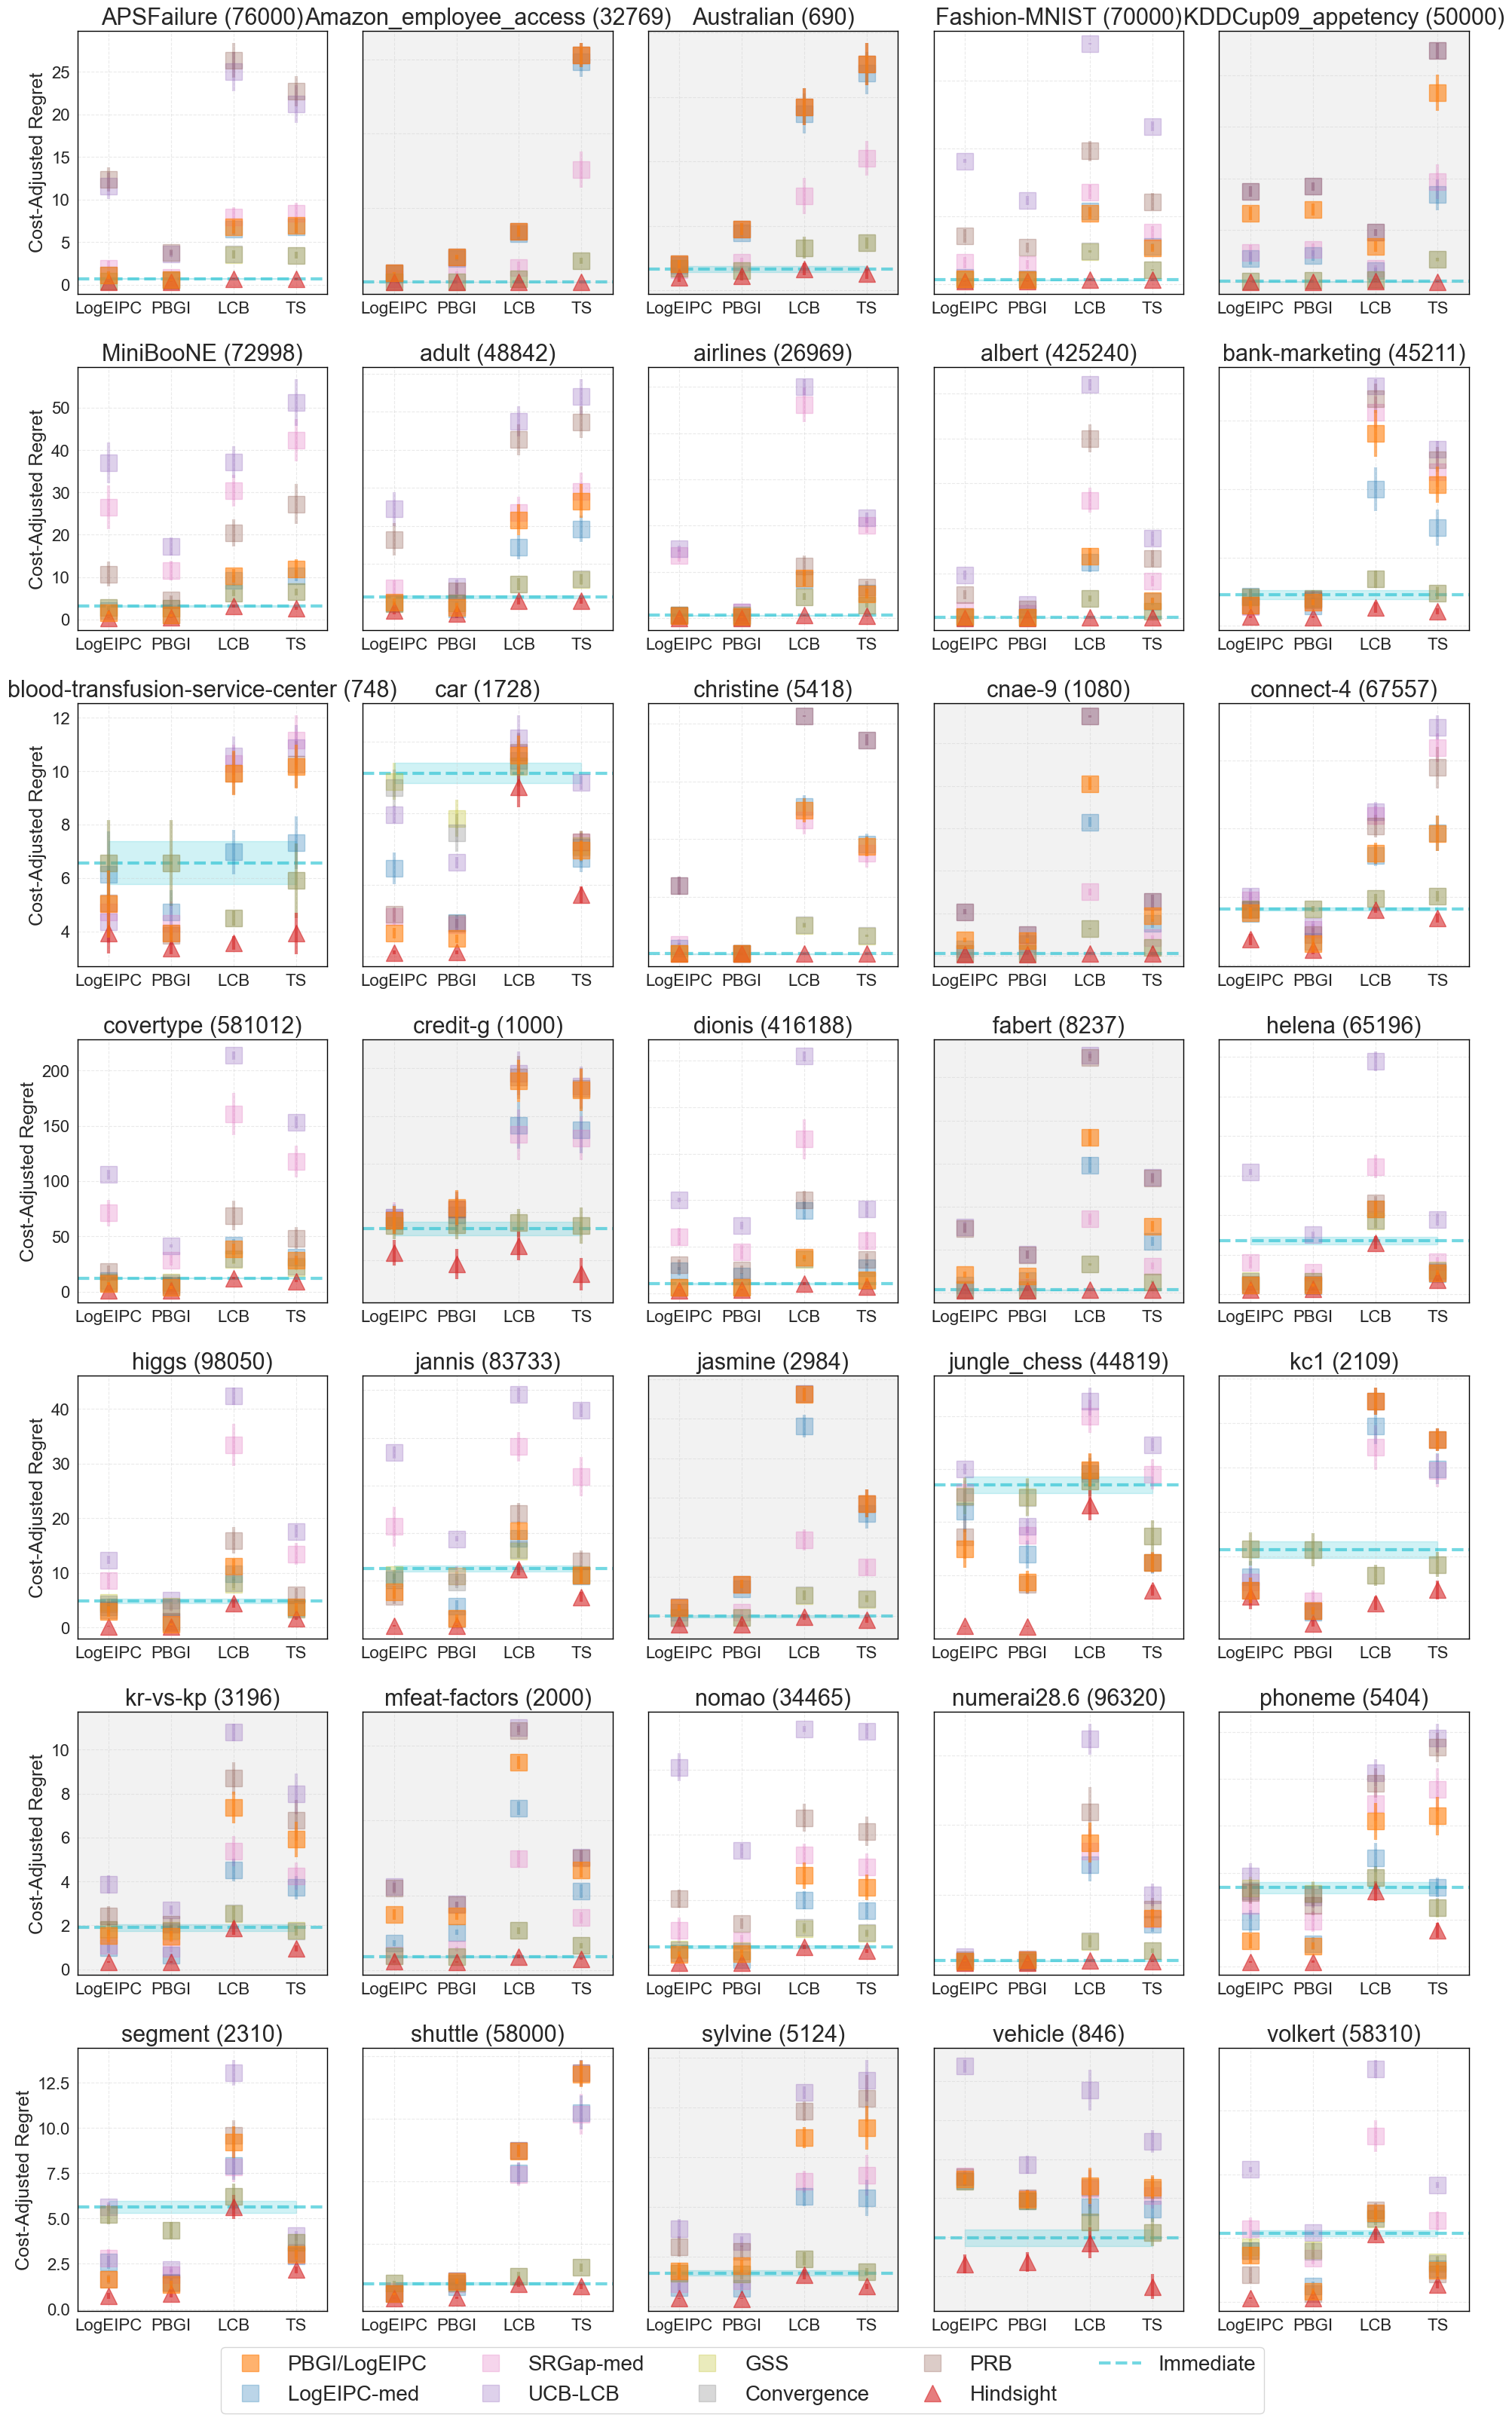

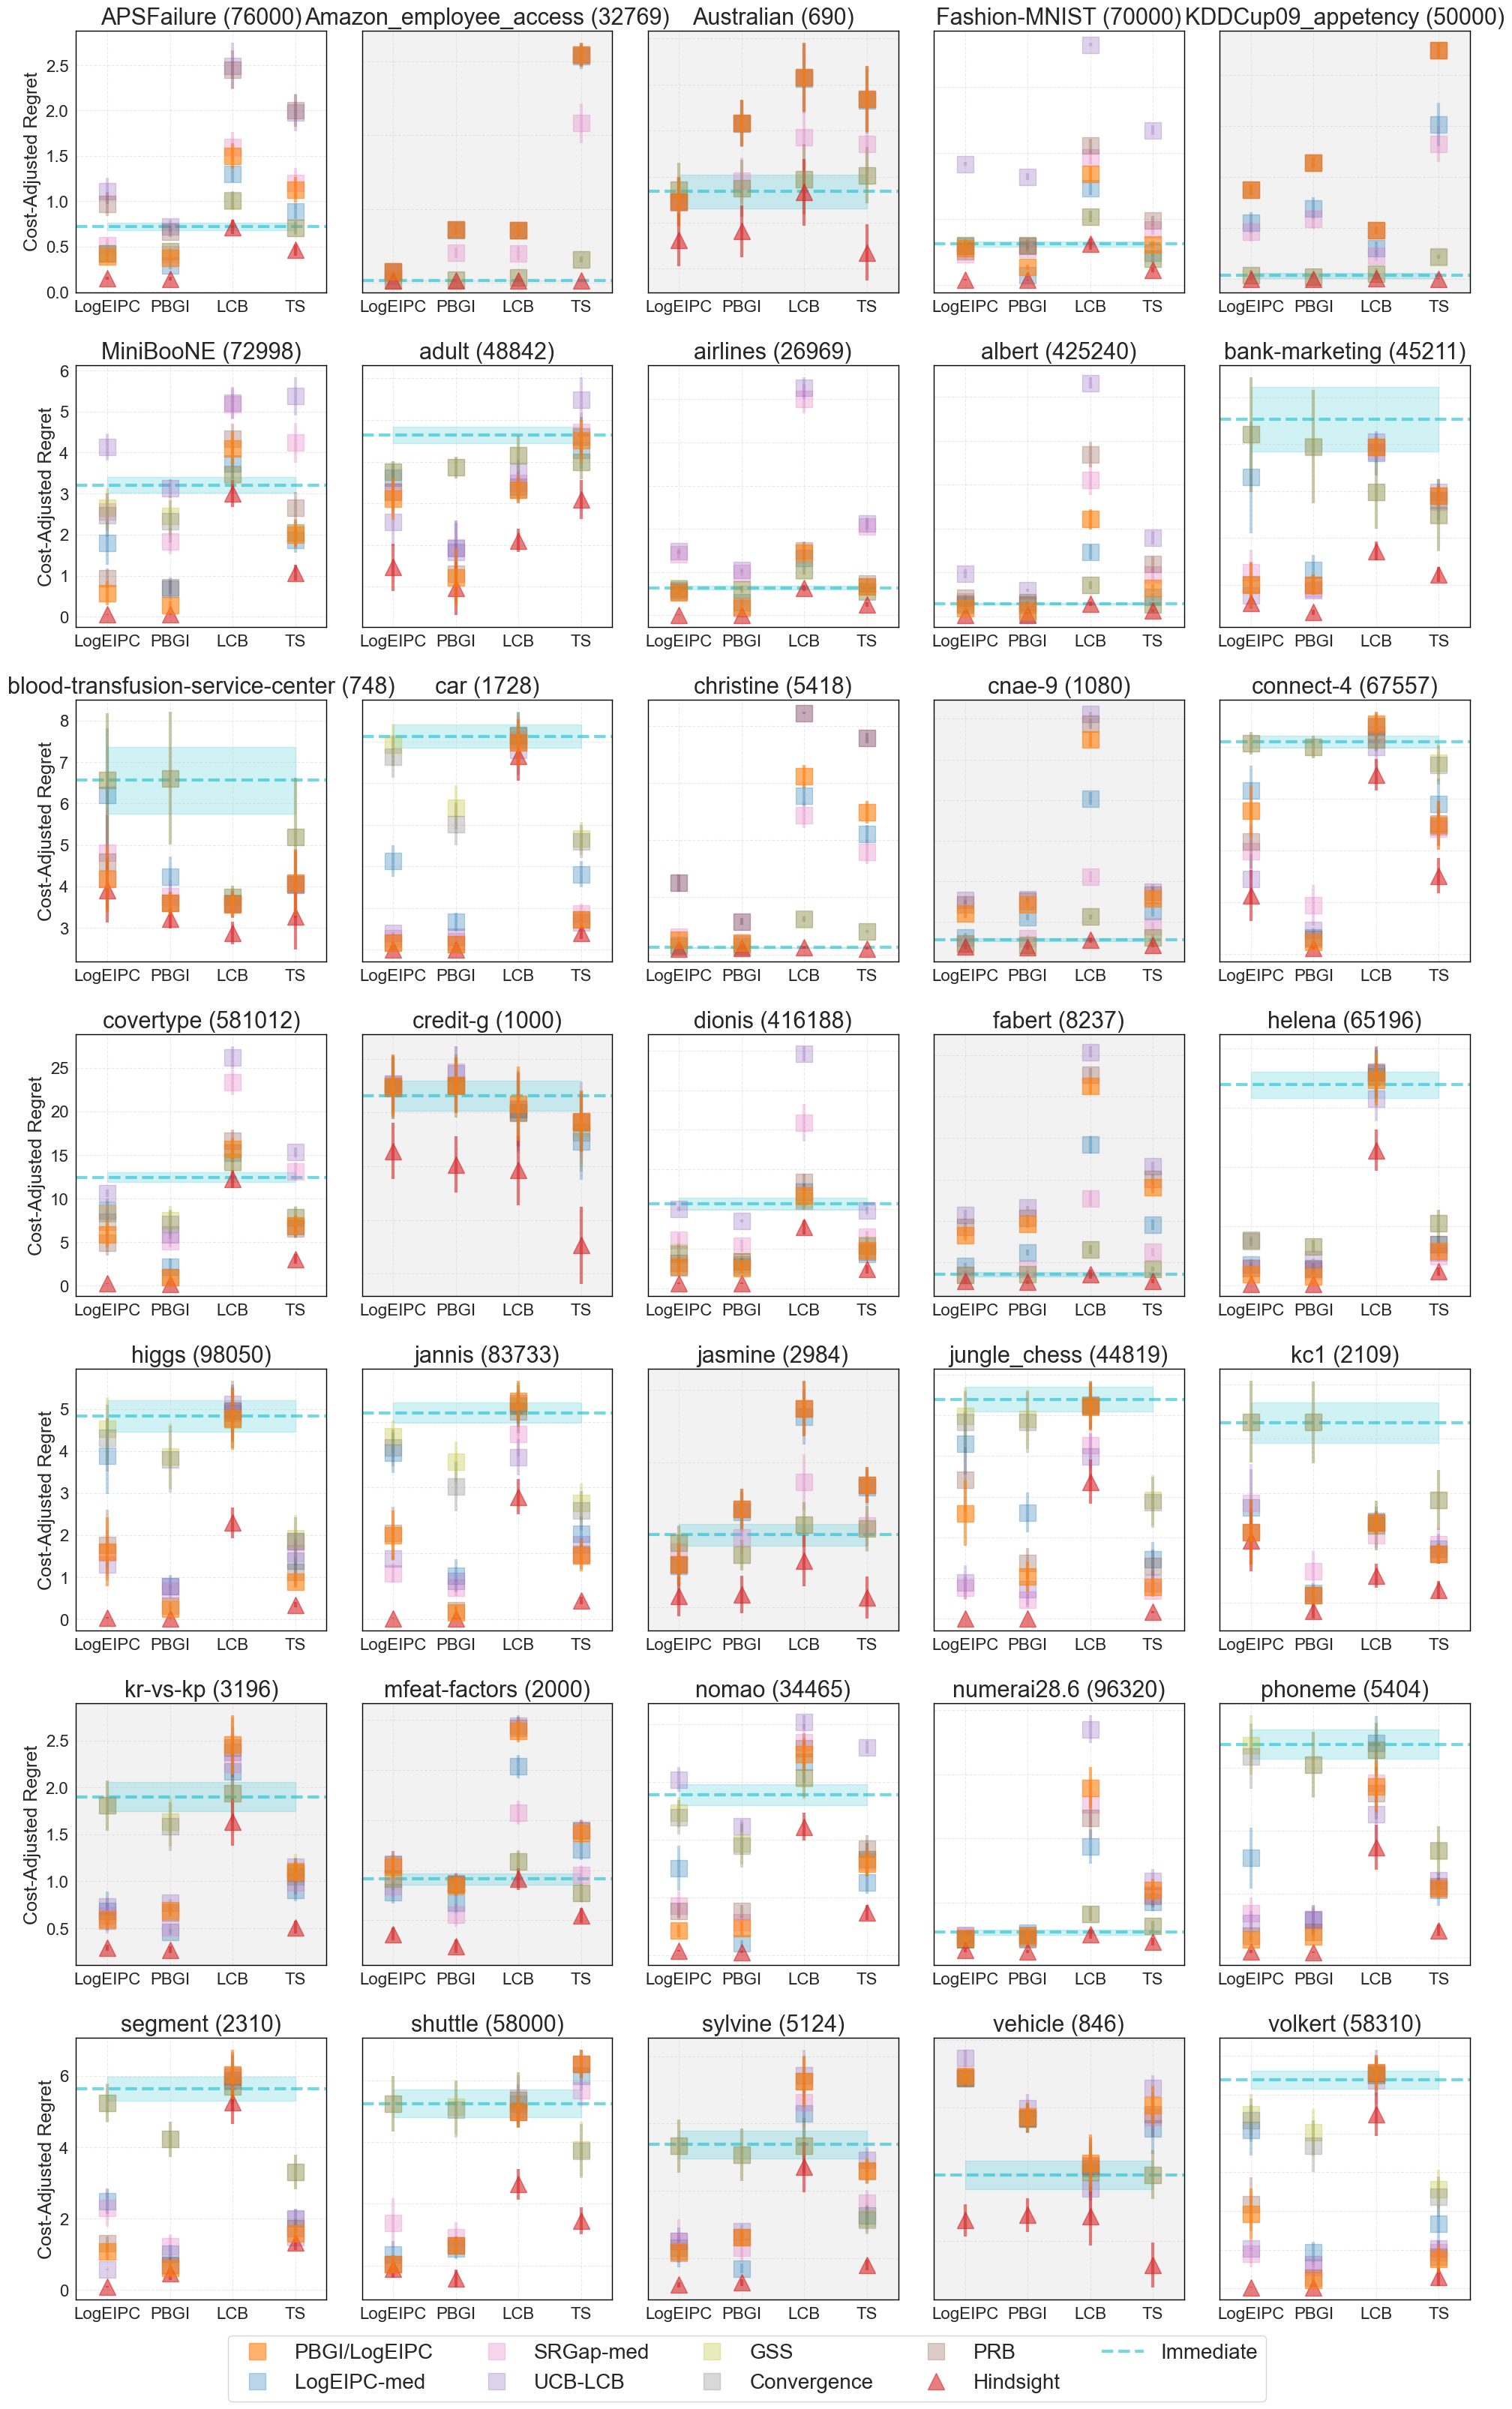

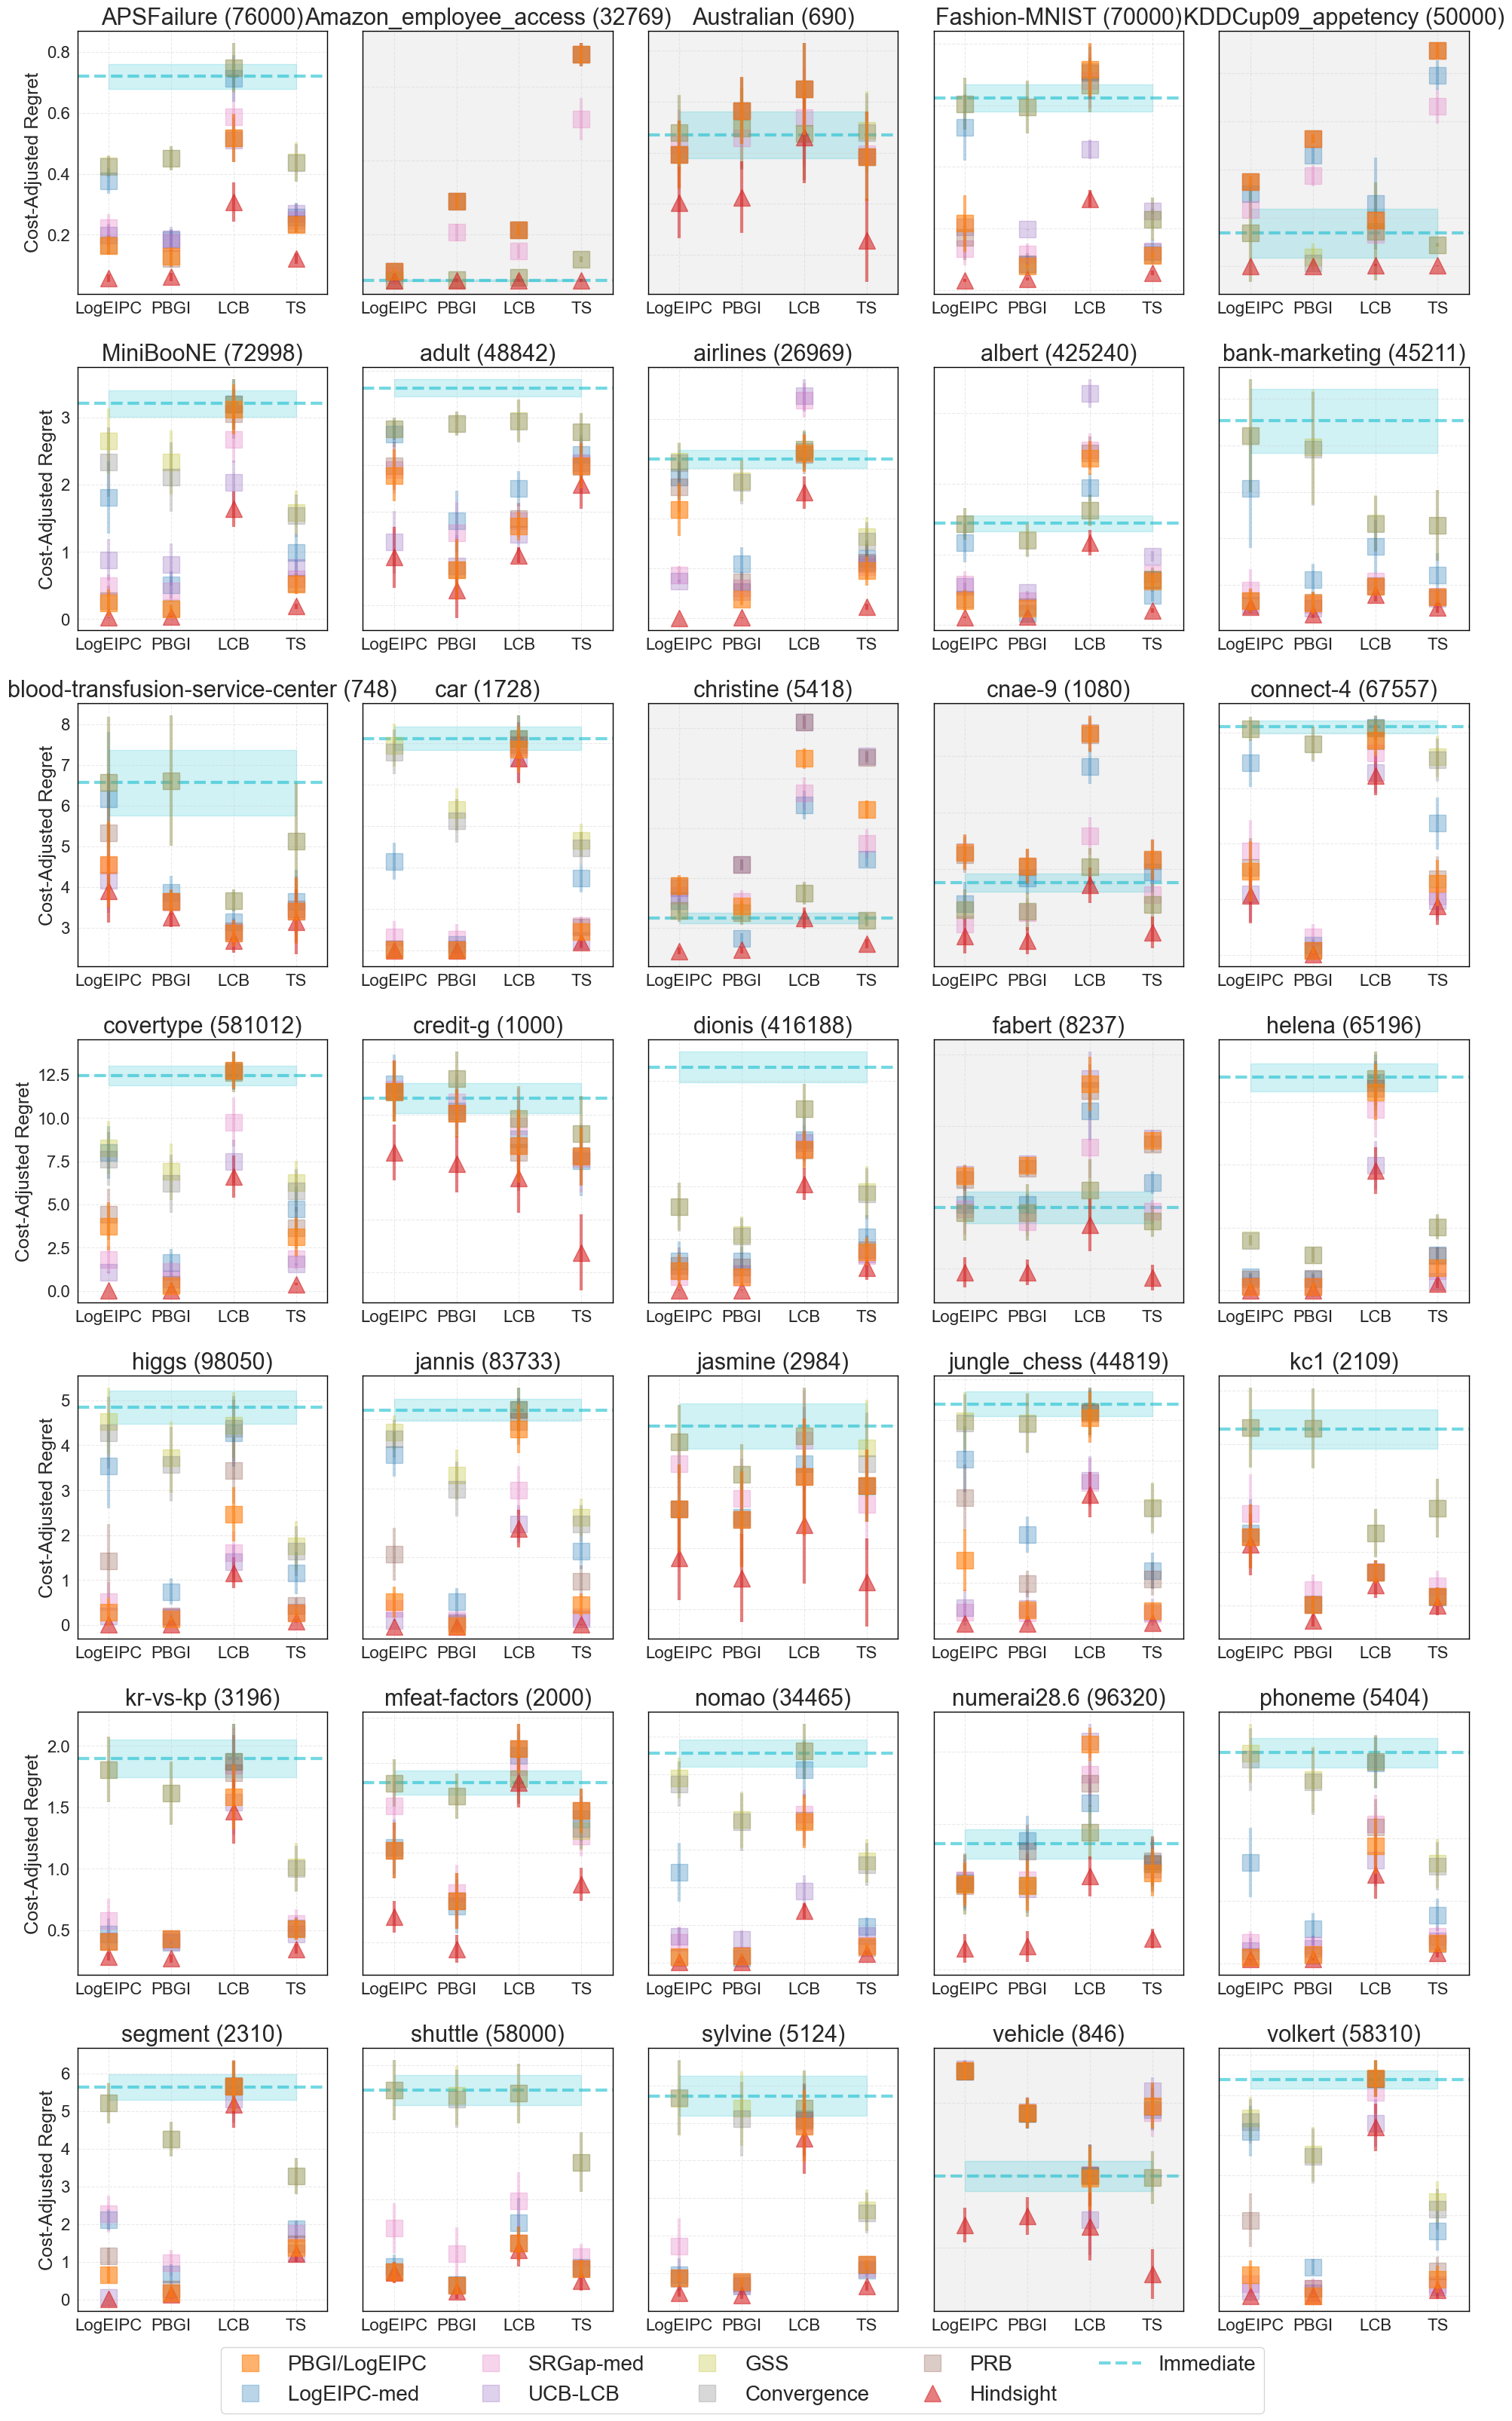

In [8]:
### Plot cost-adjusted regret (loads pre-computed results)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import dill
from math import ceil

# # Load pre-computed results
load_path = 'empirical_results/lcbench_known_cost_adjusted_regrets_all_datasets.pkl'
with open(load_path, "rb") as f:
    cost_adjusted_regrets = dill.load(f)
print(f"Loaded results from {load_path}")

# Set style
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.autolayout': False,  # we'll call tight_layout() explicitly
})


def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)

# Config
dataset_names = ['APSFailure', 'Amazon_employee_access', 'Australian', 'Fashion-MNIST', 'KDDCup09_appetency', 'MiniBooNE', 'adult', 'airlines', 'albert', 'bank-marketing', 'blood-transfusion-service-center', 'car', 'christine', 'cnae-9', 'connect-4', 'covertype', 'credit-g', 'dionis', 'fabert', 'helena', 'higgs', 'jannis', 'jasmine', 'jungle_chess_2pcs_raw_endgame_complete', 'kc1', 'kr-vs-kp', 'mfeat-factors', 'nomao', 'numerai28.6', 'phoneme', 'segment', 'shuttle', 'sylvine', 'vehicle', 'volkert']
dataset_title_map = {
    "jungle_chess_2pcs_raw_endgame_complete": "jungle_chess"
}

dataset_name_to_num_instance = {'APSFailure': 76000, 'Amazon_employee_access': 32769, 'Australian': 690, 'Fashion-MNIST': 70000, 'KDDCup09_appetency': 50000, 'MiniBooNE': 72998, 'adult': 48842, 'airlines': 26969, 'albert': 425240, 'bank-marketing': 45211, 'blood-transfusion-service-center': 748, 'car': 1728, 'christine': 5418, 'cnae-9': 1080, 'connect-4': 67557, 'covertype': 581012, 'credit-g': 1000, 'dionis': 416188, 'fabert': 8237, 'helena': 65196, 'higgs': 98050, 'jannis': 83733, 'jasmine': 2984, 'jungle_chess_2pcs_raw_endgame_complete': 44819, 'kc1': 2109, 'kr-vs-kp': 3196, 'mfeat-factors': 2000, 'nomao': 34465, 'numerai28.6': 96320, 'phoneme': 5404, 'segment': 2310, 'shuttle': 58000, 'sylvine': 5124, 'vehicle': 846, 'volkert': 58310}

lams = [1e-3, 1e-4, 1e-5]
lam_strs = ['1e-3', '1e-4', '1e-5']
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
n_cols = len(acq_order)

# Define datasets with poor performance for each lambda (to be highlighted with lightgrey background)
poor_performance_datasets = {
    '1e-3': ['Amazon_employee_access', 'Australian', 'KDDCup09_appetency', 'cnae-9', 'credit-g', 'fabert', 'jasmine', 'kr-vs-kp', 'mfeat-factors', 'sylvine', 'vehicle'],
    '1e-4': ['Amazon_employee_access', 'Australian', 'KDDCup09_appetency', 'cnae-9', 'credit-g', 'fabert', 'jasmine', 'kr-vs-kp', 'mfeat-factors', 'sylvine', 'vehicle'],
    '1e-5': ['Amazon_employee_access', 'Australian', 'KDDCup09_appetency', 'christine', 'cnae-9', 'fabert', 'vehicle']
}

# Plotting loop
for lam_order in range(len(lams)):
    lam = lams[lam_order]
    lam_str = lam_strs[lam_order]

    # Grid layout
    n_rows = 7
    n_cols_grid = 5
    fig, axes = plt.subplots(
        n_rows, n_cols_grid, figsize=(4 * n_cols_grid, 4.8 * n_rows),
        sharey=False
    )
    axes = axes.flatten()
    
    legend_handles = {}
    legend_labels = {}
    
    for idx, d in enumerate(dataset_names):
        ax = axes[idx]
        
        # Set lightgrey background for datasets with poor performance
        if d in poor_performance_datasets.get(lam_str, []):
            ax.set_facecolor('0.95')  # Very light grey (95% white)

        # --- Plot all non-Immediate rules ---
        for j, acq in enumerate(acq_order):
            for rule in stopping_rules:
                if rule['acq_key'] != f"PBGI({lam_str})":
                    continue
                if rule['stp_key'] == 'Immediate':
                    continue

                # Get pre-computed values
                mean_val = cost_adjusted_regrets[lam_str, d, acq, rule['stp_key']]
                err_val = cost_adjusted_regrets.get((lam_str, d, acq, rule['stp_key'], 'std_err'), 0)

                alpha = 0.6 if (rule['stp_key'] == 'PBGI' or rule['is_hindsight']) else 0.3
                zorder = 3 if rule['stp_key'] == 'PBGI' else 2
                marker = "^" if rule['is_hindsight'] else 's'
                handle = ax.errorbar(
                    j, mean_val, yerr=2 * err_val,
                    fmt=marker,
                    markersize=16,
                    linewidth=3.0,
                    color=rule['color'],
                    capsize=0,
                    alpha=alpha,
                    zorder=zorder,
                    label=rule['label']
                )
                
                if rule['label'] not in legend_labels:
                    legend_labels[rule['label']] = rule['label']
                    legend_handles[rule['label']] = handle[0] if isinstance(handle, tuple) else handle

        # --- Plot Immediate as horizontal line ---
        # Get Immediate values for the first acquisition function (they're the same across all)
        immediate_mean = cost_adjusted_regrets.get((lam_str, d, acq_order[0], 'Immediate'), None)
        if immediate_mean is not None:
            immediate_err = cost_adjusted_regrets.get((lam_str, d, acq_order[0], 'Immediate', 'std_err'), 0)
            
            ax.axhline(
                y=immediate_mean, xmin=0, xmax=1,
                color='tab:cyan', linestyle='--', linewidth=3.0, alpha=0.6, zorder=1
            )
            ax.fill_between(
                [0, len(acq_order)-1],
                [immediate_mean - 2*immediate_err, immediate_mean - 2*immediate_err],
                [immediate_mean + 2*immediate_err, immediate_mean + 2*immediate_err],
                color='tab:cyan', alpha=0.2, zorder=0
            )
            if 'Immediate' not in legend_labels:
                legend_labels['Immediate'] = 'Immediate'
                legend_handles['Immediate'] = plt.Line2D(
                    [0], [0],
                    color='tab:cyan', linestyle='--', linewidth=3.0, alpha=0.6
                )

        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(acq_order, fontsize=16)
        ax.set_xlim(-0.5, n_cols - 0.5)
        short_d = dataset_title_map.get(d, d)
        ax.set_title(f"{short_d} ({dataset_name_to_num_instance[d]})", fontsize=22)
        ax.grid(True, linestyle='--', alpha=0.4)
        style_spines(ax)

        # --- Only leftmost subplot in each row shows y-axis & label
        if idx % n_cols_grid == 0:
            ax.set_ylabel("Cost-Adjusted Regret", fontsize=18)
            ax.tick_params(axis='y', labelleft=True)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', labelleft=False)  # hide y tick labels on non-leftmost subplots

        ax.tick_params(labelsize=16)

    # --- Shared legend, closer to subplots
    legend_items = list(legend_handles.items())
    if 'Immediate' in legend_labels:
        immediate_item = None
        for i, (label, handle) in enumerate(legend_items):
            if label == 'Immediate':
                immediate_item = legend_items.pop(i)
                break
        if immediate_item:
            legend_items.append(immediate_item)
    
    fig.legend(
        [h for _, h in legend_items],
        [l for l, _ in legend_items],
        loc='lower center',
        bbox_to_anchor=(0.5, 0.015),  
        ncol=ceil(len(legend_items) / 2),
        fontsize=20,
        frameon=True
    )

    # Leave a bit more room at the bottom for the legend but not too much
    plt.tight_layout(rect=[0, 0.04, 1, 0.98])

    plt.savefig(f'../plots/BarPlot_LCBench_{lam_str}_all_datasets.pdf', bbox_inches='tight')
    plt.show()

After getting the cost-adjusted simple regret, we also get the rank distribution of the PBGI stopping rule when used in combination with PBGI acquisition function and logEIPC acquisition function. 

In [ ]:
import pandas as pd
import numpy as np

# Define lambdas and their string representations
def initialize_cost_adjusted_regrets_ranks(cost_adjusted_regrets_ranks):
    for acq in acq_order:
        cost_adjusted_regrets_ranks[acq] = {}
        for stop_rule in stop_rule_names:
            cost_adjusted_regrets_ranks[acq][stop_rule] = {}
            for lam_str in lambda_strs:
                cost_adjusted_regrets_ranks[acq][stop_rule][lam_str] = {}
                for rank in range(len(stop_rule_names)):
                    cost_adjusted_regrets_ranks[acq][stop_rule][lam_str][rank] = 0

def set_and_display_cost_adjusted_regrets_ranks(cost_adjusted_regrets, datasets, stop_rule_names, lambda_strs, acq_order):
    cost_adjusted_regrets_ranks = {} 
    initialize_cost_adjusted_regrets_ranks(cost_adjusted_regrets_ranks)
    for l_idx, lam_str in enumerate(lambda_strs):
        # For every dataset, get cost-adjusted regret for PBGI for each stopping rule
        for dataset in datasets:
            for acq in acq_order:
                vals = np.zeros(len(stop_rule_names))
                for stop_rule_order, stop_rule in enumerate(stop_rule_names):
                    regret_val = cost_adjusted_regrets[lam_str, dataset, acq, stop_rule]
                    vals[stop_rule_order] = regret_val
                # Rank, 0 is the best (smallest regret)
                ranks = vals.argsort().argsort()  # Lower rank is better (0=best)
                for stop_rule_order in range(len(stop_rule_names)):
                    cost_adjusted_regrets_ranks[acq][stop_rule_names[stop_rule_order]][lam_str][ranks[stop_rule_order]] += 1
    pbgi_ranks = cost_adjusted_regrets_ranks['PBGI']['PBGI']
    logeipc_ranks = cost_adjusted_regrets_ranks['LogEIPC']['PBGI']
    df_pbgi_rank = pd.DataFrame(pbgi_ranks)
    df_logeipc_rank = pd.DataFrame(logeipc_ranks)
    print("PBGI+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:")
    display(df_pbgi_rank)
    print("LogEIPC+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:")
    display(df_logeipc_rank)


lambda_strs = ['1e-3', '1e-4', '1e-5']
# 'Immediate'
stop_rule_names = ['Convergence', 'GSS', 'SRGap-med', 'PRB', 'UCB-LCB', 'PBGI', 'LogEIPC-med']
acq_order = ['LogEIPC', 'PBGI', 'LCB', 'TS']
num_stop_rules = len(stop_rule_names)
# Build an array: [#Ranks (1st,2nd,...), #lambdas]

In [ ]:
datasets = list(set([x[1] for x in cost_adjusted_regrets.keys()]))
set_and_display_cost_adjusted_regrets_ranks(cost_adjusted_regrets, datasets, stop_rule_names, lambda_strs, acq_order)

PBGI+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,7,10,10
1,10,8,8
2,4,4,8
3,3,6,3
4,8,2,0
5,0,1,4
6,3,4,2


LogEIPC+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,11,8,7
1,5,8,10
2,6,8,8
3,5,3,3
4,6,5,1
5,0,1,4
6,2,2,2


In [ ]:
# Filter datasets to only keep those with > 10,000 instances
medium_to_large_datasets = [d for d, n in dataset_name_to_num_instance.items() if n > 10000]
# print("Datasets with > 10,000 instances:", medium_to_large_datasets)
set_and_display_cost_adjusted_regrets_ranks(cost_adjusted_regrets, medium_to_large_datasets, stop_rule_names, lambda_strs, acq_order)

PBGI+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,4,8,10
1,10,6,4
2,2,2,4
3,0,2,0
4,3,0,0
5,0,0,1
6,1,2,1


LogEIPC+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,8,6,4
1,5,4,6
2,1,7,7
3,4,1,1
4,1,0,0
5,0,0,1
6,1,2,1


In [ ]:
small_datasets = [d for d, n in dataset_name_to_num_instance.items() if n <= 10000]
# print("Datasets with <= 10,000 instances:", small_datasets)
set_and_display_cost_adjusted_regrets_ranks(cost_adjusted_regrets, small_datasets, stop_rule_names, lambda_strs, acq_order)


PBGI+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,3,2,0
1,0,2,4
2,2,2,4
3,3,4,3
4,5,2,0
5,0,1,3
6,2,2,1


LogEIPC+PBGI/LogEIPC Stop Rule Rankings (across all datasets) for each lambda:


,1e-3,1e-4,1e-5
0,3,2,3
1,0,4,4
2,5,1,1
3,1,2,2
4,5,5,1
5,0,1,3
6,1,0,1
